# Exercise:
* Source: https://www.learnpytorch.io/01_pytorch_workflow/#exercises

## Train and Test Loop

Epoch: 0 | Train Loss: 0.4182 | Test Loss: 0.3114
Epoch: 1 | Train Loss: 0.4067 | Test Loss: 0.298
Epoch: 2 | Train Loss: 0.3952 | Test Loss: 0.2845
Epoch: 3 | Train Loss: 0.3836 | Test Loss: 0.271
Epoch: 4 | Train Loss: 0.3721 | Test Loss: 0.2576
Epoch: 5 | Train Loss: 0.3606 | Test Loss: 0.2441
Epoch: 6 | Train Loss: 0.3491 | Test Loss: 0.2306
Epoch: 7 | Train Loss: 0.3376 | Test Loss: 0.2171
Epoch: 8 | Train Loss: 0.326 | Test Loss: 0.2037
Epoch: 9 | Train Loss: 0.3145 | Test Loss: 0.1902
Epoch: 10 | Train Loss: 0.303 | Test Loss: 0.1767
Epoch: 11 | Train Loss: 0.2915 | Test Loss: 0.1633
Epoch: 12 | Train Loss: 0.28 | Test Loss: 0.1498
Epoch: 13 | Train Loss: 0.2684 | Test Loss: 0.1363
Epoch: 14 | Train Loss: 0.2569 | Test Loss: 0.1229
Epoch: 15 | Train Loss: 0.2454 | Test Loss: 0.1094
Epoch: 16 | Train Loss: 0.2339 | Test Loss: 0.0959
Epoch: 17 | Train Loss: 0.2224 | Test Loss: 0.0824
Epoch: 18 | Train Loss: 0.2108 | Test Loss: 0.069
Epoch: 19 | Train Loss: 0.1993 | Test Loss: 0.05

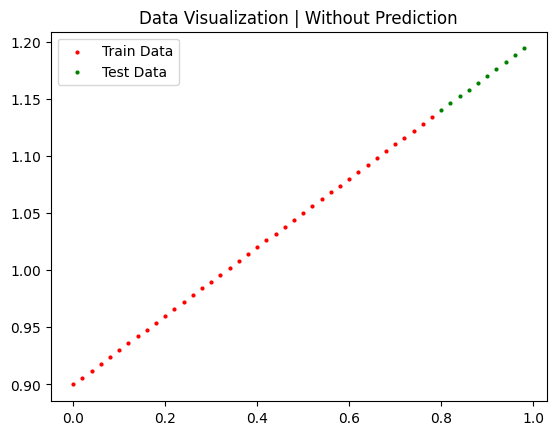

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from pathlib import Path

# Ground Truth
weight = 0.3
bias = 0.9
X = torch.arange(0., 1., 0.02).unsqueeze(dim=1)
y = weight * X + bias

# Data Split
train_split = int(0.8 * len(X))
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

# Data Visualization
def plot_prediction(train_data, train_label, test_data, test_label, prediction=None):
    plt.title(f'Data Visualization | {'Without Prediction' if prediction is None else 'With Prediction'}')
    plt.scatter(train_data, train_label, s=4, c='r', label='Train Data')
    plt.scatter(test_data, test_label, s=4, c='g', label='Test Data')
    if prediction is not None:
        plt.scatter(test_data, prediction, s=4, c='b', label='Prediction')
    plt.legend()

plot_prediction(train_data=X_train, train_label=y_train, test_data=X_test, test_label=y_test)

# Model Definition
class LinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear_layer = nn.Linear(in_features=1, out_features=1)
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.linear_layer(x)


# Training loop
## Setup
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model_0 = LinearRegressionModel().to(device)
X_train, X_test, y_train, y_test = X_train.to(device), X_test.to(device), y_train.to(device), y_test.to(device)
loss_fn = nn.L1Loss()
optimizer = torch.optim.SGD(model_0.parameters(), 1e-2)
EPOCHS = 5000

## Keep track of results
plt_epochs = []
plt_train_losses = []
plt_test_losses = []

for epoch in range(EPOCHS):
    
    # Training
    model_0.train()
    y_preds = model_0(X_train)
    train_loss = loss_fn(y_preds, y_train)

    optimizer.zero_grad()
    train_loss.backward()
    optimizer.step()

    # Testing
    model_0.eval()
    with torch.inference_mode():
        y_preds_eval = model_0(X_test)
        test_loss = loss_fn(y_preds_eval, y_test)

    # Print result
    print(f'Epoch: {epoch} | Train Loss: {round(train_loss.item(), 4)} | Test Loss: {round(test_loss.item(), 4)}')

    # Save result for results
    if epoch % 100 == 0:
        plt_epochs.append(epoch)
        plt_train_losses.append(train_loss.item())
        plt_test_losses.append(test_loss.item())
    




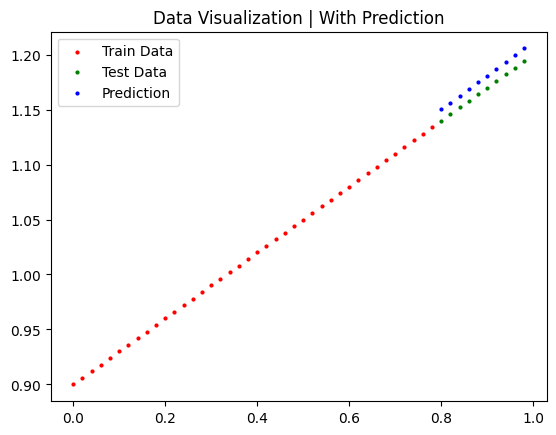

In [6]:
## Result Visualization
model_0.eval()
with torch.inference_mode():
    prediction = model_0(X_test)

plot_prediction(train_data=X_train.cpu(), train_label=y_train.cpu(), test_data=X_test.cpu(), test_label=y_test.cpu(), prediction=prediction.cpu())

## Save and Load Model

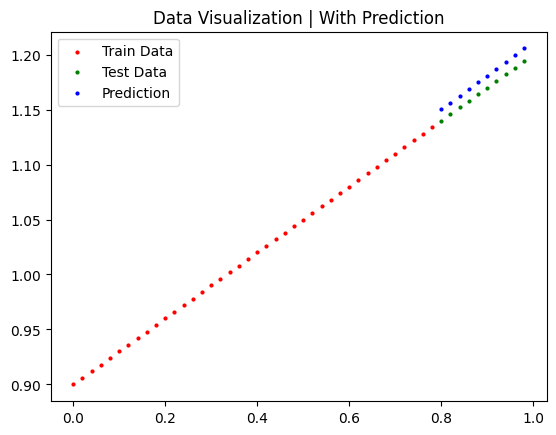

In [10]:
# Save A Model
save_folder = Path('models')
save_folder.mkdir(parents=True, exist_ok=True)
save_path = save_folder / 'model_0.pt'

torch.save(model_0.state_dict(), save_path)

# Load A model
model_0_v1 = LinearRegressionModel().to(device)
model_0_v1.load_state_dict(torch.load(save_path, weights_only=True))

# Test loaded model
model_0_v1.eval()
with torch.inference_mode():
    predictions = model_0_v1(X_test)

plot_prediction(train_data=X_train.cpu(), train_label=y_train.cpu(), test_data=X_test.cpu(), test_label=y_test.cpu(), prediction=predictions.cpu())